In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import itertools


In [ ]:
curve_df = pd.read_hdf('./data/data.h5', key='curve_data')
sample_info = pd.read_hdf('./data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('./data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('./data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})
val_pred = pd.read_csv('./data/model_outputs/fusion_val_pred_df.csv')
test_pred = pd.read_csv('./data/model_outputs/fusion_test_pred_df.csv')

In [236]:
gru_val_pred = pd.read_csv('./data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('./data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

In [237]:
val_pred = val_pred[val_pred.curve_idx.isin(gru_val_pred.curve_idx)]
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

In [238]:
groundtruth_df.head()

,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,groundtruth_label,encoded_igi_call
0,24933,S gene,Negative Control (qPCR),S252611,Negative,1,195418.72,195418.718750,-1,train,0,0
1,24933,S gene,Negative Control (qPCR),S252611,Negative,2,195288.33,195288.328125,-1,train,0,0
2,24933,S gene,Negative Control (qPCR),S252611,Negative,3,194651.67,194651.671875,-1,train,0,0
3,24933,S gene,Negative Control (qPCR),S252611,Negative,4,194355.02,194355.015625,-1,train,0,0
4,24933,S gene,Negative Control (qPCR),S252611,Negative,5,194165.97,194165.968750,-1,train,0,0


In [239]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))


In [240]:
val_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'val', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(val_pred, how='inner', on = 'curve_idx'))
val_pred_df = val_pred_df.rename(columns={'prob':'outputs'})
test_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})

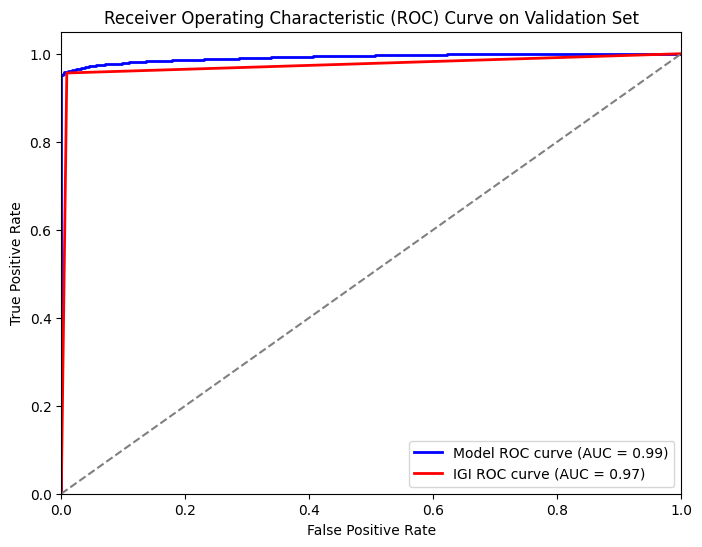

In [241]:
val_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.outputs)
val_fpr, val_tpr, val_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.outputs)

val_igi_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
val_igi_fpr, val_igi_tpr, val_igi_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(val_fpr, val_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(val_auc))
plt.plot(val_igi_fpr, val_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(val_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.show()


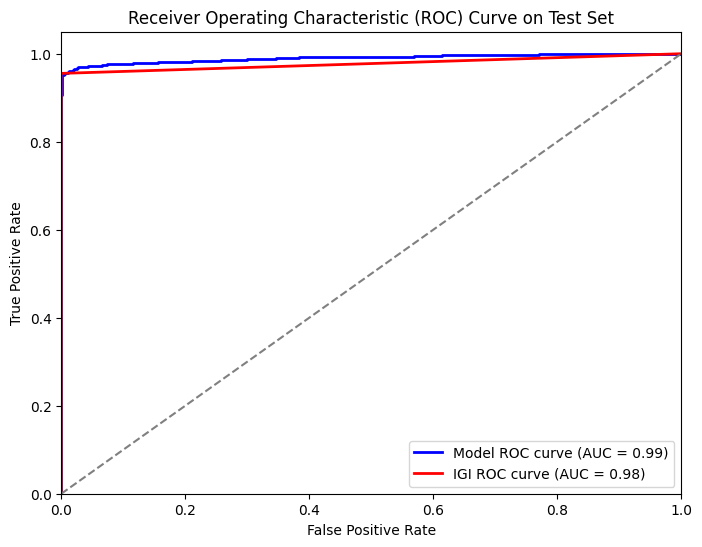

In [242]:
test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


In [243]:
igi_recall = recall_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_precision = precision_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_tn = sum((val_pred_df.groundtruth_label == val_pred_df.encoded_igi_call) & (val_pred_df.encoded_igi_call == 0))

# print('IGI true positive:', igi_tp)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI true negatives:', igi_tn)

IGI precision score: 0.9989952273298166
IGI recall score: 0.9562394806443857
IGI true negatives: 445


In [263]:
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
tnrs, precisions, recalls = [], [], []
for thres in thresholds:
    pred = 1*(val_pred_df.outputs >= thres)
    tnrs.append(sum((val_pred_df.groundtruth_label == 0) & (val_pred_df.groundtruth_label == pred)))
    precisions.append(precision_score(val_pred_df.groundtruth_label, pred, zero_division=0))
    recalls.append(recall_score(val_pred_df.groundtruth_label, pred))

threshold_idx = tnrs.index(445)
matched_thres = thresholds[threshold_idx]
print('Threshold to match IGI true negatives:', matched_thres)
print('With matching threshold, model precision:', precisions[threshold_idx])
print('With matching threshold, model recall:', recalls[threshold_idx])

Threshold to match IGI true negatives: 0.6252252252252252
With matching threshold, model precision: 0.99899849774662
With matching threshold, model recall: 0.9593652320269296


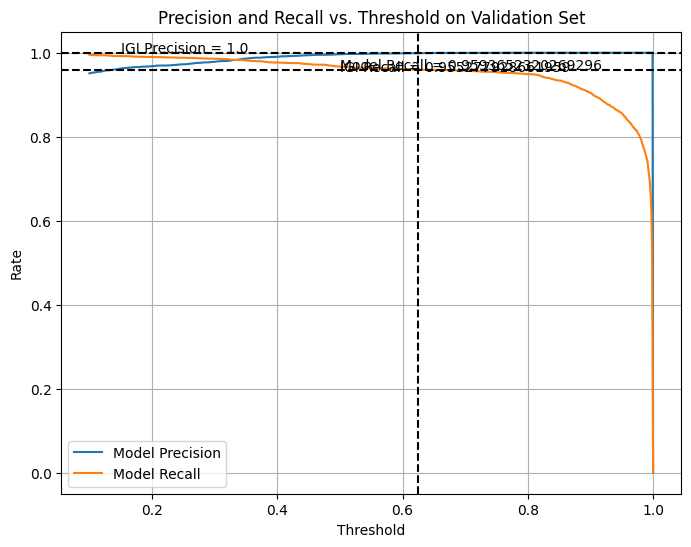

In [264]:



# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, label='Model Precision')
plt.plot(thresholds, recalls, label='Model Recall')
plt.axhline(igi_precision, color = 'black', linestyle='--')
plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, igi_precision), xytext=(0.15, 1))
plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
plt.axhline(recalls[threshold_idx], color = 'black', linestyle='--')
plt.annotate(f'Model Recall = {recalls[threshold_idx]}', xy=(0.1, recalls[threshold_idx]), xytext=(0.5, recalls[threshold_idx]*1.001))
plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, recalls[threshold_idx]), xytext=(0.5, recalls[threshold_idx]*0.996))
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Precision and Recall vs. Threshold on Validation Set")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


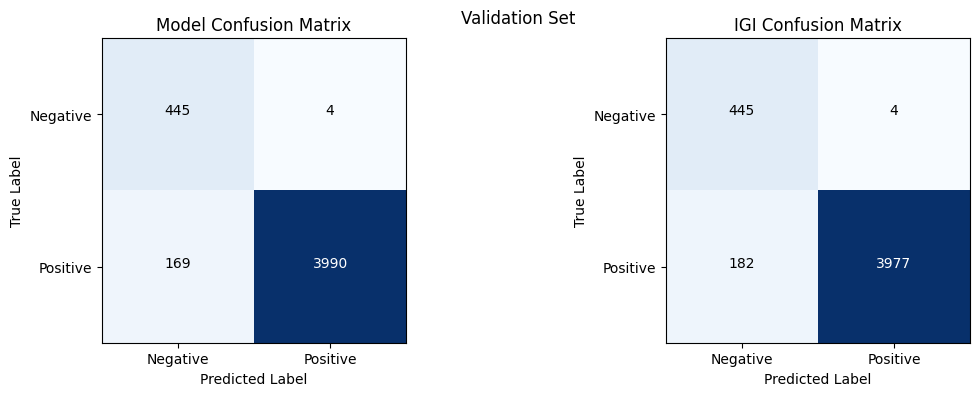

In [265]:
matched_preds = 1*(val_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(val_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.tight_layout()
fig.suptitle('Validation Set')
plt.show()


In [266]:
val_pred_df.loc[:,'matched_pred'] = matched_preds
print('Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, round(val_pred_df.matched_pred)))
print('IGI Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.72      0.99      0.84       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.86      0.98      0.91      4608
weighted avg       0.97      0.96      0.96      4608

IGI Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.85      0.97      0.90      4608
weighted avg       0.97      0.96      0.96      4608



In [267]:
diff_df = val_pred_df.loc[val_pred_df.encoded_igi_call != val_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 81


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
285,103252,1,0,0.790140,1
397,65980,0,0,0.645296,1
409,30828,0,0,0.747156,1
421,43940,1,1,0.445443,0
424,322,1,1,0.478761,0


29135
86000
86384
128362


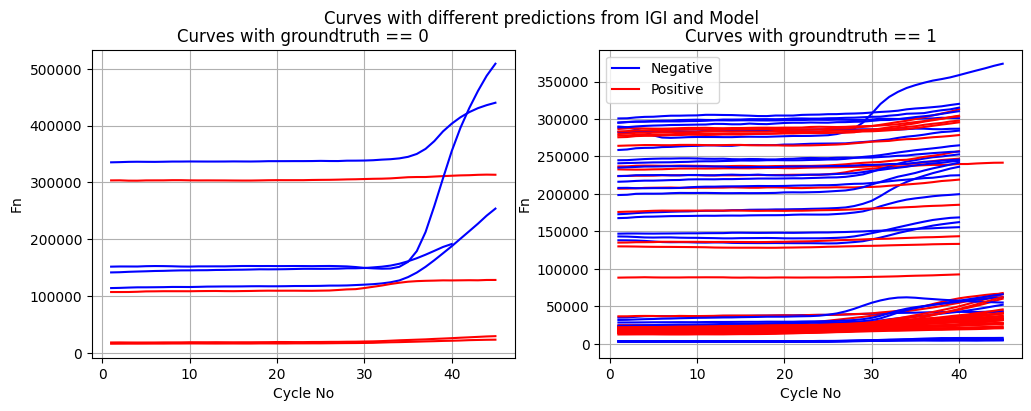

In [268]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            print(idx)
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
axes[1].legend()
fig.suptitle('Curves with different predictions from IGI and Model')
plt.show()

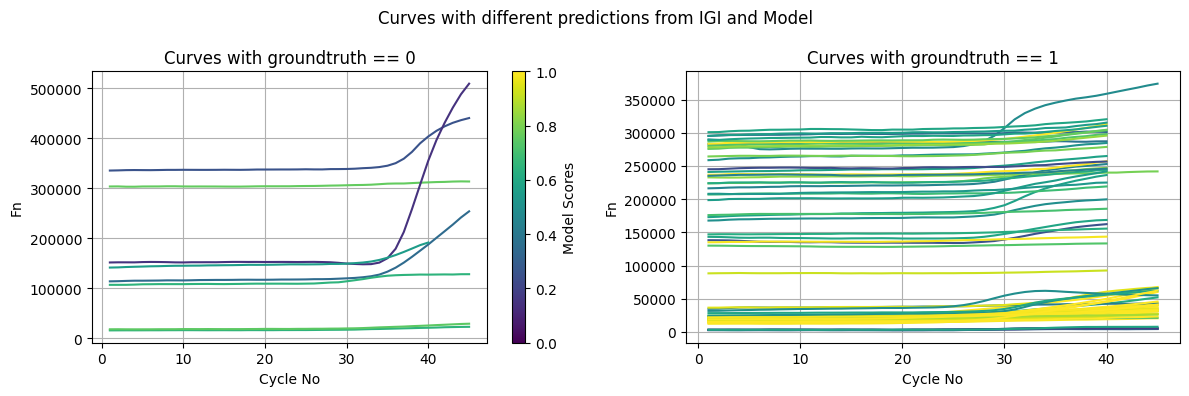

In [269]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax = axes[0])
fig.suptitle('Curves with different predictions from IGI and Model')
plt.tight_layout()
plt.show()

In [270]:
val_sample_df = (val_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

val_sample_df.loc[:,'sample_type'] = val_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
val_sample_pred = (val_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in model prediction is: ', (sum(val_sample_pred.matched_pred.isin([0,1]))/val_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(val_sample_pred.encoded_igi_call.isin([0,1]))/val_sample_pred.shape[0]))

Agreement rate between genes in model prediction is:  0.9719626168224299
Agreement rate between genes in IGI prediction is:  0.985981308411215


## Test set

In [273]:
igi_recall = recall_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
igi_precision = precision_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
igi_tn = sum((test_pred_df.groundtruth_label == test_pred_df.encoded_igi_call) & (test_pred_df.encoded_igi_call == 0))

print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI true negatives:', igi_tn)

IGI precision score: 1.0
IGI recall score: 0.955277928661959
IGI true negatives: 621


Threshold to match IGI true negatives: 0.8954954954954955
With matching threshold, model precision: 1.0
With matching threshold, model recall: 0.9072967590077856


/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


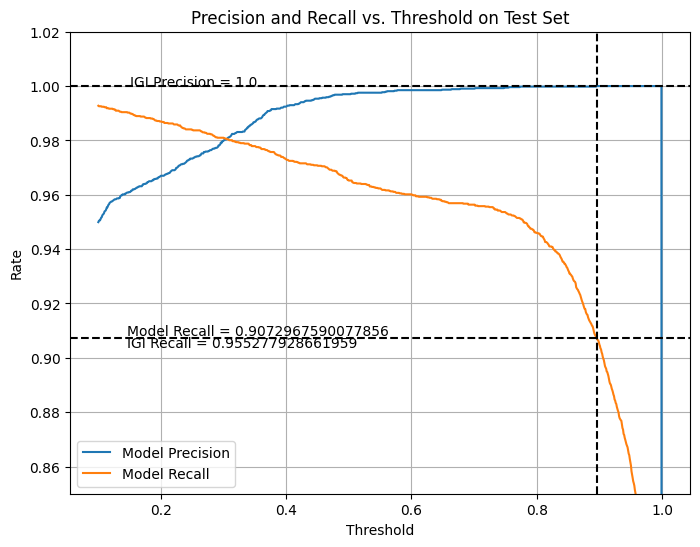

In [274]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
tnrs, precisions, recalls = [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    tnrs.append(sum((test_pred_df.groundtruth_label == 0) & (test_pred_df.groundtruth_label == pred)))
    precisions.append(precision_score(test_pred_df.groundtruth_label, pred))
    recalls.append(recall_score(test_pred_df.groundtruth_label, pred))

threshold_idx = tnrs.index(621)
matched_thres = thresholds[threshold_idx]
print('Threshold to match IGI true negatives:', matched_thres)
print('With matching threshold, model precision:', precisions[threshold_idx])
print('With matching threshold, model recall:', recalls[threshold_idx])

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, label='Model Precision')
plt.plot(thresholds, recalls, label='Model Recall')
plt.axhline(igi_precision, color = 'black', linestyle='--')
plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, igi_precision), xytext=(0.15, igi_precision))
plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
plt.axhline(recalls[threshold_idx], color = 'black', linestyle='--')
plt.annotate(f'Model Recall = {recalls[threshold_idx]}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*1.001))
plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*0.996))
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.ylim((0.85,1.02))
plt.title("Precision and Recall vs. Threshold on Test Set")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


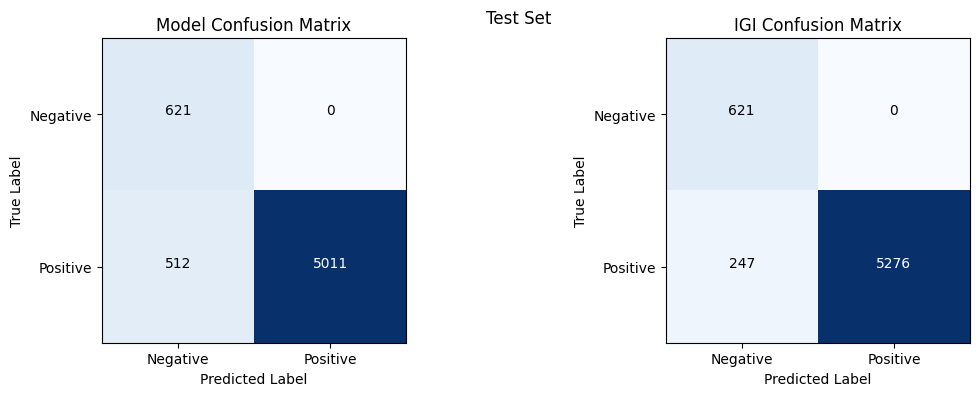

In [275]:
matched_preds = 1*(test_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(test_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
fig.suptitle('Test Set')
plt.show()


In [276]:
test_pred_df.loc[:,['matched_pred']] = matched_preds
print('Model confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.matched_pred)))
print('IGI confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.encoded_igi_call)))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.55      1.00      0.71       621
           1       1.00      0.91      0.95      5523

    accuracy                           0.92      6144
   macro avg       0.77      0.95      0.83      6144
weighted avg       0.95      0.92      0.93      6144

IGI confusion matrix
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       621
           1       1.00      0.96      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.91      6144
weighted avg       0.97      0.96      0.96      6144



In [277]:

diff_df = test_pred_df.loc[test_pred_df.encoded_igi_call != test_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 337


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
390,103226,1,1,0.394801,0
391,103610,1,1,0.794873,0
393,103250,1,1,0.640007,0
426,8676,1,1,0.649498,0
441,4922,1,1,0.266288,0


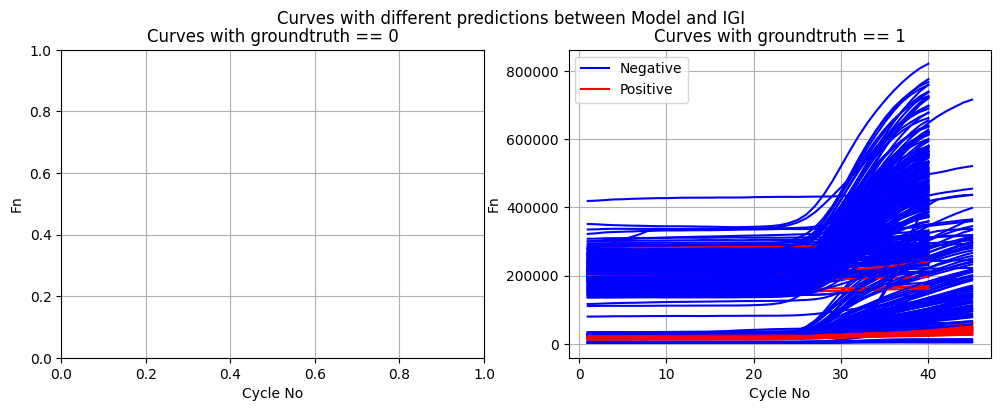

In [278]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.legend()
plt.show()

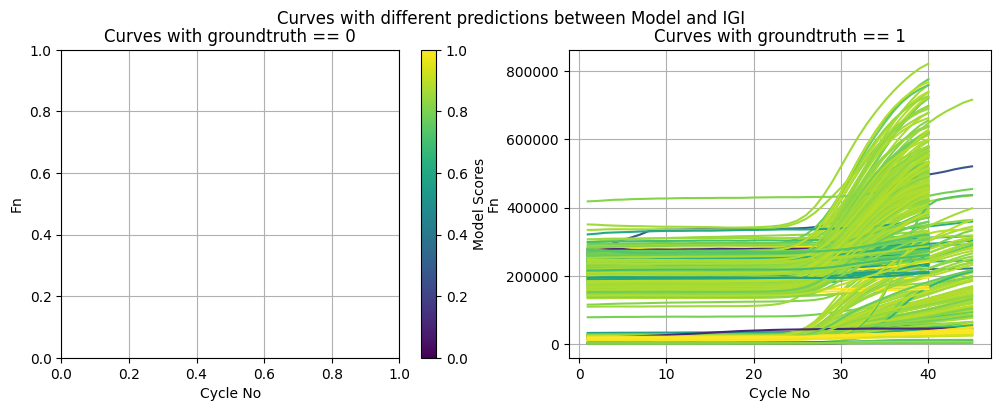

In [279]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1) #, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1) #, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax=axes[0])
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()

In [280]:
test_sample_df = (test_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

test_sample_df.loc[:,'sample_type'] = test_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
test_sample_pred = (test_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in Model prediction is: ', (sum(test_sample_pred.matched_pred.isin([0,1]))/test_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(test_sample_pred.encoded_igi_call.isin([0,1]))/test_sample_pred.shape[0]))

Agreement rate between genes in Model prediction is:  0.9344827586206896
Agreement rate between genes in IGI prediction is:  0.9896551724137931


### Other genes validation

Agreement rate between genes in fusion prediction is:  0.9767441860465116
Agreement rate between genes in IGI prediction is:  0.986046511627907
